# Cell 1: Setup and  Configuration


This cell handles the specific folder paths for the  dataset.

In [1]:
!pip install -q segmentation-models-pytorch albumentations

import os, cv2, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:00


In [2]:
class UNetConfig:
    root = "/kaggle/input/datasets/samriddhibagchi/unified-retinal-lesion-dataset/unified_shuffled" 

    img_dir  = os.path.join(root, "images")
    mask_dir = os.path.join(root, "masks")

    img_size   = 512
    batch_size = 8          # ↑ increase (you now have ~2200 samples)
    lr         = 3e-4
    epochs     = 40         # ↓ less epochs needed now
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    val_size   = 0.15

all_imgs = sorted(os.listdir(UNetConfig.img_dir))

train_imgs, val_imgs = train_test_split(
    all_imgs,
    test_size=UNetConfig.val_size,
    random_state=42,
    shuffle=True
)

print(f"✅ Split: {len(train_imgs)} train | {len(val_imgs)} val")

✅ Split: 940 train | 166 val


# Cell 2: The Multi-Channel Dataset Loader


This is the most important part. It looks into each lesion folder, finds the corresponding mask for an image, and stacks them into a single 4-channel ground truth.

In [3]:
class UnifiedSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_names, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_names = img_names
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
    
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"❌ Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
        mask_path = os.path.join(self.mask_dir, img_name.replace(".png", ".npy"))
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"❌ Mask not found: {mask_path}")
    
        # ✅ FIX: (4, H, W) → (H, W, 4) for albumentations
        mask = np.load(mask_path).transpose(1, 2, 0).astype(np.float32)
    
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask'].permute(2, 0, 1)  # (H, W, 4) → (4, H, W)
    
        return image, mask.float()

## Tranforms

In [4]:
train_transform = A.Compose([
    A.Resize(UNetConfig.img_size, UNetConfig.img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),  # ✅ not p=1.0
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(UNetConfig.img_size, UNetConfig.img_size),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),
    A.Normalize(),
    ToTensorV2(),
])

## Dataset init

In [5]:
train_ds = UnifiedSegDataset(
    UNetConfig.img_dir,
    UNetConfig.mask_dir,
    train_imgs,
    transform=train_transform
)
val_ds = UnifiedSegDataset(
    UNetConfig.img_dir,
    UNetConfig.mask_dir,
    val_imgs,
    transform=val_transform
)

## DataLoaders

In [6]:
train_loader = DataLoader(
    train_ds,
    batch_size=UNetConfig.batch_size,
    shuffle=True,
    num_workers=2,  # ✅ 4 can cause issues on Kaggle, 2 is safer
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=UNetConfig.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print(f"✅ Loaders ready: {len(train_ds)} train | {len(val_ds)} val")

✅ Loaders ready: 940 train | 166 val


Cell 3: Architecture & Loss Function

Using U-Net++ with an EfficientNet-B0 backbone. This allows the model to leverage ImageNet features while using the nested skip connections of U-Net++ to find tiny microaneurysms.


We use a combination of Binary Cross Entropy and Dice Loss.$$L = \alpha \cdot BCE + (1-\alpha) \cdot Dice$$

In [7]:
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.85, beta=0.15, gamma=1.2, smooth=1e-6):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, logits, targets, weights=None):
        probs = torch.sigmoid(logits)
        P = probs.view(probs.shape[0], probs.shape[1], -1)
        T = targets.view(targets.shape[0], targets.shape[1], -1)

        TP = (P * T).sum(dim=2)
        FP = (P * (1 - T)).sum(dim=2)
        FN = ((1 - P) * T).sum(dim=2)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
        focal   = (1 - tversky) ** self.gamma  # (B, C)

        # ✅ Apply per-channel weights if provided
        if weights is not None:
            w = weights.view(1, -1).to(focal.device)  # (1, C)
            focal = focal * w

        return focal.mean()


class HybridLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.tversky = FocalTverskyLoss()
        self.bce     = smp.losses.SoftBCEWithLogitsLoss()
        # MA=4x, HE=3x because they're rare and clinically critical
        # EX=1x, SE=2x — SE is rarest so upweight it
        self.class_weights = torch.tensor([4.0, 3.0, 1.0, 2.0])

    def forward(self, logits, targets):
        weights = self.class_weights.to(logits.device)
        tversky_loss = self.tversky(logits, targets, weights=weights)
        bce_loss     = self.bce(logits, targets)
        return 0.7 * tversky_loss + 0.3 * bce_loss

Cell 4: The "Bridge" – Feature Extraction for Phase 3


This function is what makes your research unique. It converts the U-Net's visual output into numbers for your XGBoost Meta-Learner.

In [8]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4,
    activation=None
).to(UNetConfig.device)

criterion = HybridLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=UNetConfig.lr, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=UNetConfig.lr,
    epochs=UNetConfig.epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

# ✅ Quick sanity check — confirm model output shape before training
with torch.no_grad():
    dummy = torch.randn(2, 3, UNetConfig.img_size, UNetConfig.img_size).to(UNetConfig.device)
    out   = model(dummy)
    print(f"✅ Model output shape: {out.shape}")  # expect (2, 4, 512, 512)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Trainable parameters: {total_params:,}")
print(f"✅ Model on {UNetConfig.device} | Loss: FocalTversky+BCE | Scheduler: OneCycleLR")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model output shape: torch.Size([2, 4, 512, 512])
✅ Trainable parameters: 13,625,228
✅ Model on cuda | Loss: FocalTversky+BCE | Scheduler: OneCycleLR


Cell 5

In [9]:
def extract_clinical_features(mask_tensor, img_size=512):
    """
    Converts (4, H, W) mask into 16 clinical metrics (4 per channel).
    Channels: MA=0, HE=1, EX=2, SE=3
    """
    if torch.is_tensor(mask_tensor):
        mask_np = mask_tensor.detach().cpu().numpy()
    else:
        mask_np = mask_tensor

    feats = {}
    names       = ['MA', 'HE', 'EX', 'SE']
    total_pixels = img_size * img_size

    for i, name in enumerate(names):
        channel = (mask_np[i] > 0.5).astype(np.uint8)

        # Metric 1: Area (total lesion pixels)
        area = int(np.sum(channel))
        feats[f'{name}_area'] = area

        # Metric 2: Density (area / total image pixels)
        feats[f'{name}_density'] = area / total_pixels

        # Metric 3: Count (number of distinct lesion blobs)
        num_labels, label_map = cv2.connectedComponents(channel)
        count = max(0, num_labels - 1)
        feats[f'{name}_count'] = count

        # Metric 4: Mean blob size (avg pixels per lesion)
        # Clinically important — large HE blobs = worse prognosis than many tiny MAs
        if count > 0:
            blob_sizes = [
                np.sum(label_map == lbl)
                for lbl in range(1, num_labels)
            ]
            feats[f'{name}_mean_blob_size'] = float(np.mean(blob_sizes))
        else:
            feats[f'{name}_mean_blob_size'] = 0.0

    # ✅ Cross-channel feature: total lesion burden across all channels
    # Single most predictive feature for DR grade
    feats['total_lesion_density'] = sum(
        feats[f'{n}_density'] for n in names
    )

    return feats  # 17 features total


# ✅ Quick test
dummy_mask = np.zeros((4, 512, 512), dtype=np.float32)
dummy_mask[0, 100:120, 100:120] = 1.0  # fake MA lesion
dummy_mask[2, 200:250, 200:280] = 1.0  # fake EX lesion

feats = extract_clinical_features(dummy_mask)
print(f"Feature count : {len(feats)}")
print(f"Features      : {list(feats.keys())}")
print(f"MA area       : {feats['MA_area']}")
print(f"EX density    : {feats['EX_density']:.6f}")
print(f"Total burden  : {feats['total_lesion_density']:.6f}")

Feature count : 17
Features      : ['MA_area', 'MA_density', 'MA_count', 'MA_mean_blob_size', 'HE_area', 'HE_density', 'HE_count', 'HE_mean_blob_size', 'EX_area', 'EX_density', 'EX_count', 'EX_mean_blob_size', 'SE_area', 'SE_density', 'SE_count', 'SE_mean_blob_size', 'total_lesion_density']
MA area       : 400
EX density    : 0.015259
Total burden  : 0.016785


Cell 6

In [10]:
scaler = GradScaler(enabled=torch.cuda.is_available())

def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Training", leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        # ✅ FIX: autocast should be no-op on CPU
        with autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss    = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    tp, fp, fn, tn = [], [], [], []

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        with autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss    = criterion(outputs, masks)

        total_loss += loss.item()

        # ✅ FIX: pass logits directly to get_stats, use consistent threshold
        # Don't manually threshold then pass threshold=0.5 — pick one approach
        stats = smp.metrics.get_stats(
            outputs, masks.long(),
            mode='multilabel',
            threshold=0.4   # consistent with your clinical preference
        )
        tp.append(stats[0])
        fp.append(stats[1])
        fn.append(stats[2])
        tn.append(stats[3])

    tp_s = torch.cat(tp).sum(0)
    fp_s = torch.cat(fp).sum(0)
    fn_s = torch.cat(fn).sum(0)
    tn_s = torch.cat(tn).sum(0)

    per_class = smp.metrics.f1_score(tp_s, fp_s, fn_s, tn_s, reduction="none")
    macro     = smp.metrics.f1_score(tp_s, fp_s, fn_s, tn_s, reduction="macro")

    return {
        "loss"    : total_loss / len(loader),
        "dice"    : macro.item(),
        "ma_dice" : per_class[0].item(),
        "he_dice" : per_class[1].item(),
        "ex_dice" : per_class[2].item(),
        "se_dice" : per_class[3].item(),
    }

In [11]:
def check_visuals(model, dataset, device, num_samples=3):
    model.eval()

    LESION_COLORS = [
        [255, 100, 100],   # MA  — red
        [255, 165,   0],   # HE  — orange (was dark red, hard to see)
        [255, 255,   0],   # EX  — yellow
        [0,   255, 100],   # SE  — green
    ]
    LESION_NAMES = ['MA', 'HE', 'EX', 'SE']
    THRESHOLD    = 0.4   # ✅ consistent with validate_epoch

    # ✅ FIX: define once outside the loop
    def create_color_mask(m):
        h, w    = m.shape[1], m.shape[2]
        overlay = np.zeros((h, w, 3), dtype=np.uint8)
        for ch in range(4):
            binary = (m[ch] > THRESHOLD).astype(np.uint8)
            for c in range(3):
                overlay[:, :, c] += binary * LESION_COLORS[ch][c]
        return np.clip(overlay, 0, 255)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 6 * num_samples))

    for i in range(num_samples):
        img, mask = dataset[i]

        # Denormalize for display
        display_img = img.permute(1, 2, 0).numpy() * std + mean
        display_img = np.clip(display_img, 0, 1)

        # Predict
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))
            pred   = torch.sigmoid(logits).cpu().numpy()[0]  # (4, H, W)

        # ✅ FIX: mask from dataset is (4, H, W) tensor — convert correctly
        mask_np = mask.numpy() if torch.is_tensor(mask) else mask

        axes[i, 0].imshow(display_img)
        axes[i, 0].set_title(f"Sample {i+1}: Original Retina", fontsize=12)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(create_color_mask(mask_np))
        axes[i, 1].set_title("Expert Ground Truth", fontsize=12)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(create_color_mask(pred))
        axes[i, 2].set_title("U-Net Prediction", fontsize=12)
        axes[i, 2].axis('off')

    # ✅ ADD: legend so teammates know what each color means
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=np.array(LESION_COLORS[i])/255, label=LESION_NAMES[i])
        for i in range(4)
    ]
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=4,
        fontsize=12,
        title="Lesion Channels",
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.tight_layout()
    plt.show()

print("✅ Visual Auditor ready.")

✅ Visual Auditor ready.


🚀 Training on 940 | Validating on 166


Training:   0%|          | 0/118 [00:00<?, ?it/s]


--- Epoch 1/40 ---
LR: 0.000054
Train Loss: 1.9339 | Val Dice: 0.0043
📊 MA: 0.000 | HE: 0.004 | EX: 0.017 | SE: 0.002
⭐ Best overall model saved!
⭐ Best MA+HE model saved!


Training:   0%|          | 0/118 [00:00<?, ?it/s]


--- Epoch 2/40 ---
LR: 0.000156
Train Loss: 1.8649 | Val Dice: 0.0808
📊 MA: 0.000 | HE: 0.166 | EX: 0.002 | SE: 0.020
⭐ Best overall model saved!
⭐ Best MA+HE model saved!


...


--- Epoch 22/40 ---
LR: 0.000150
Train Loss: 1.2652 | Val Dice: 0.4927
📊 MA: 0.207 | HE: 0.473 | EX: 0.565 | SE: 0.452


Training:   0%|          | 0/118 [00:00<?, ?it/s]


--- Epoch 23/40 ---
LR: 0.000137
Train Loss: 1.2638 | Val Dice: 0.5102
📊 MA: 0.212 | HE: 0.496 | EX: 0.575 | SE: 0.475
⭐ Best overall model saved!


Training:   0%|          | 0/118 [00:00<?, ?it/s]


--- Epoch 24/40 ---
LR: 0.000124
Train Loss: 1.2586 | Val Dice: 0.5071
📊 MA: 0.207 | HE: 0.491 | EX: 0.578 | SE: 0.464
⏹ Early stopping at epoch 24 (no MA+HE improvement for 15 epochs)

✅ Best Overall Dice : 0.5102
✅ Best MA+HE Score  : 0.7780


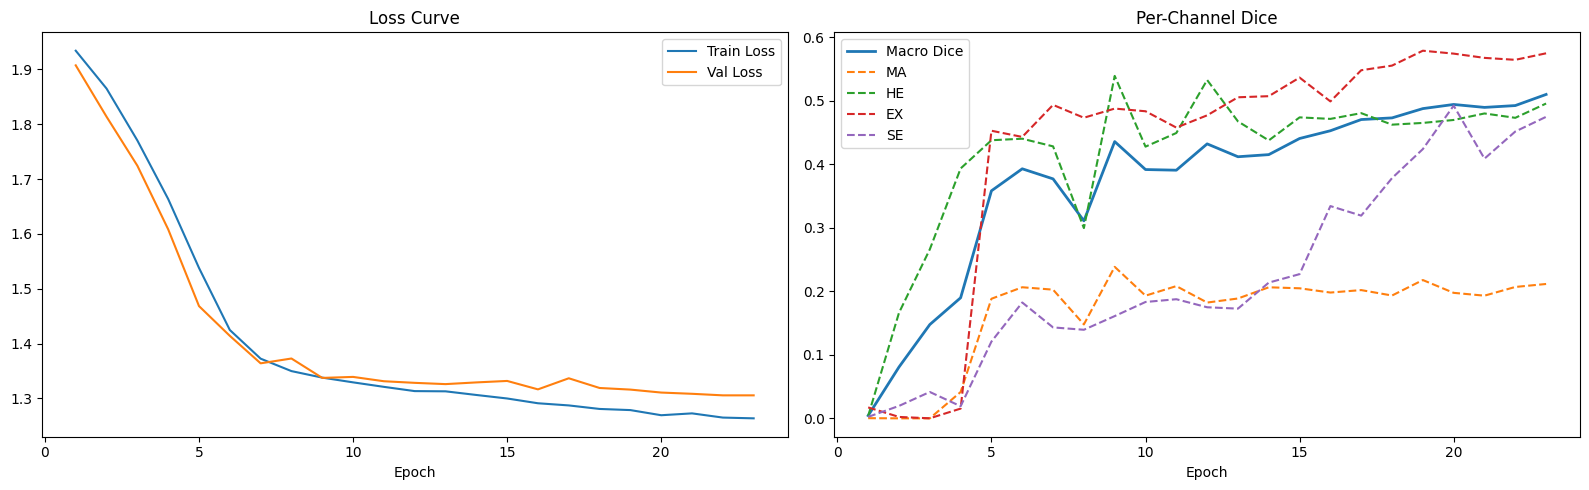


🔍 Final Visual Audit...


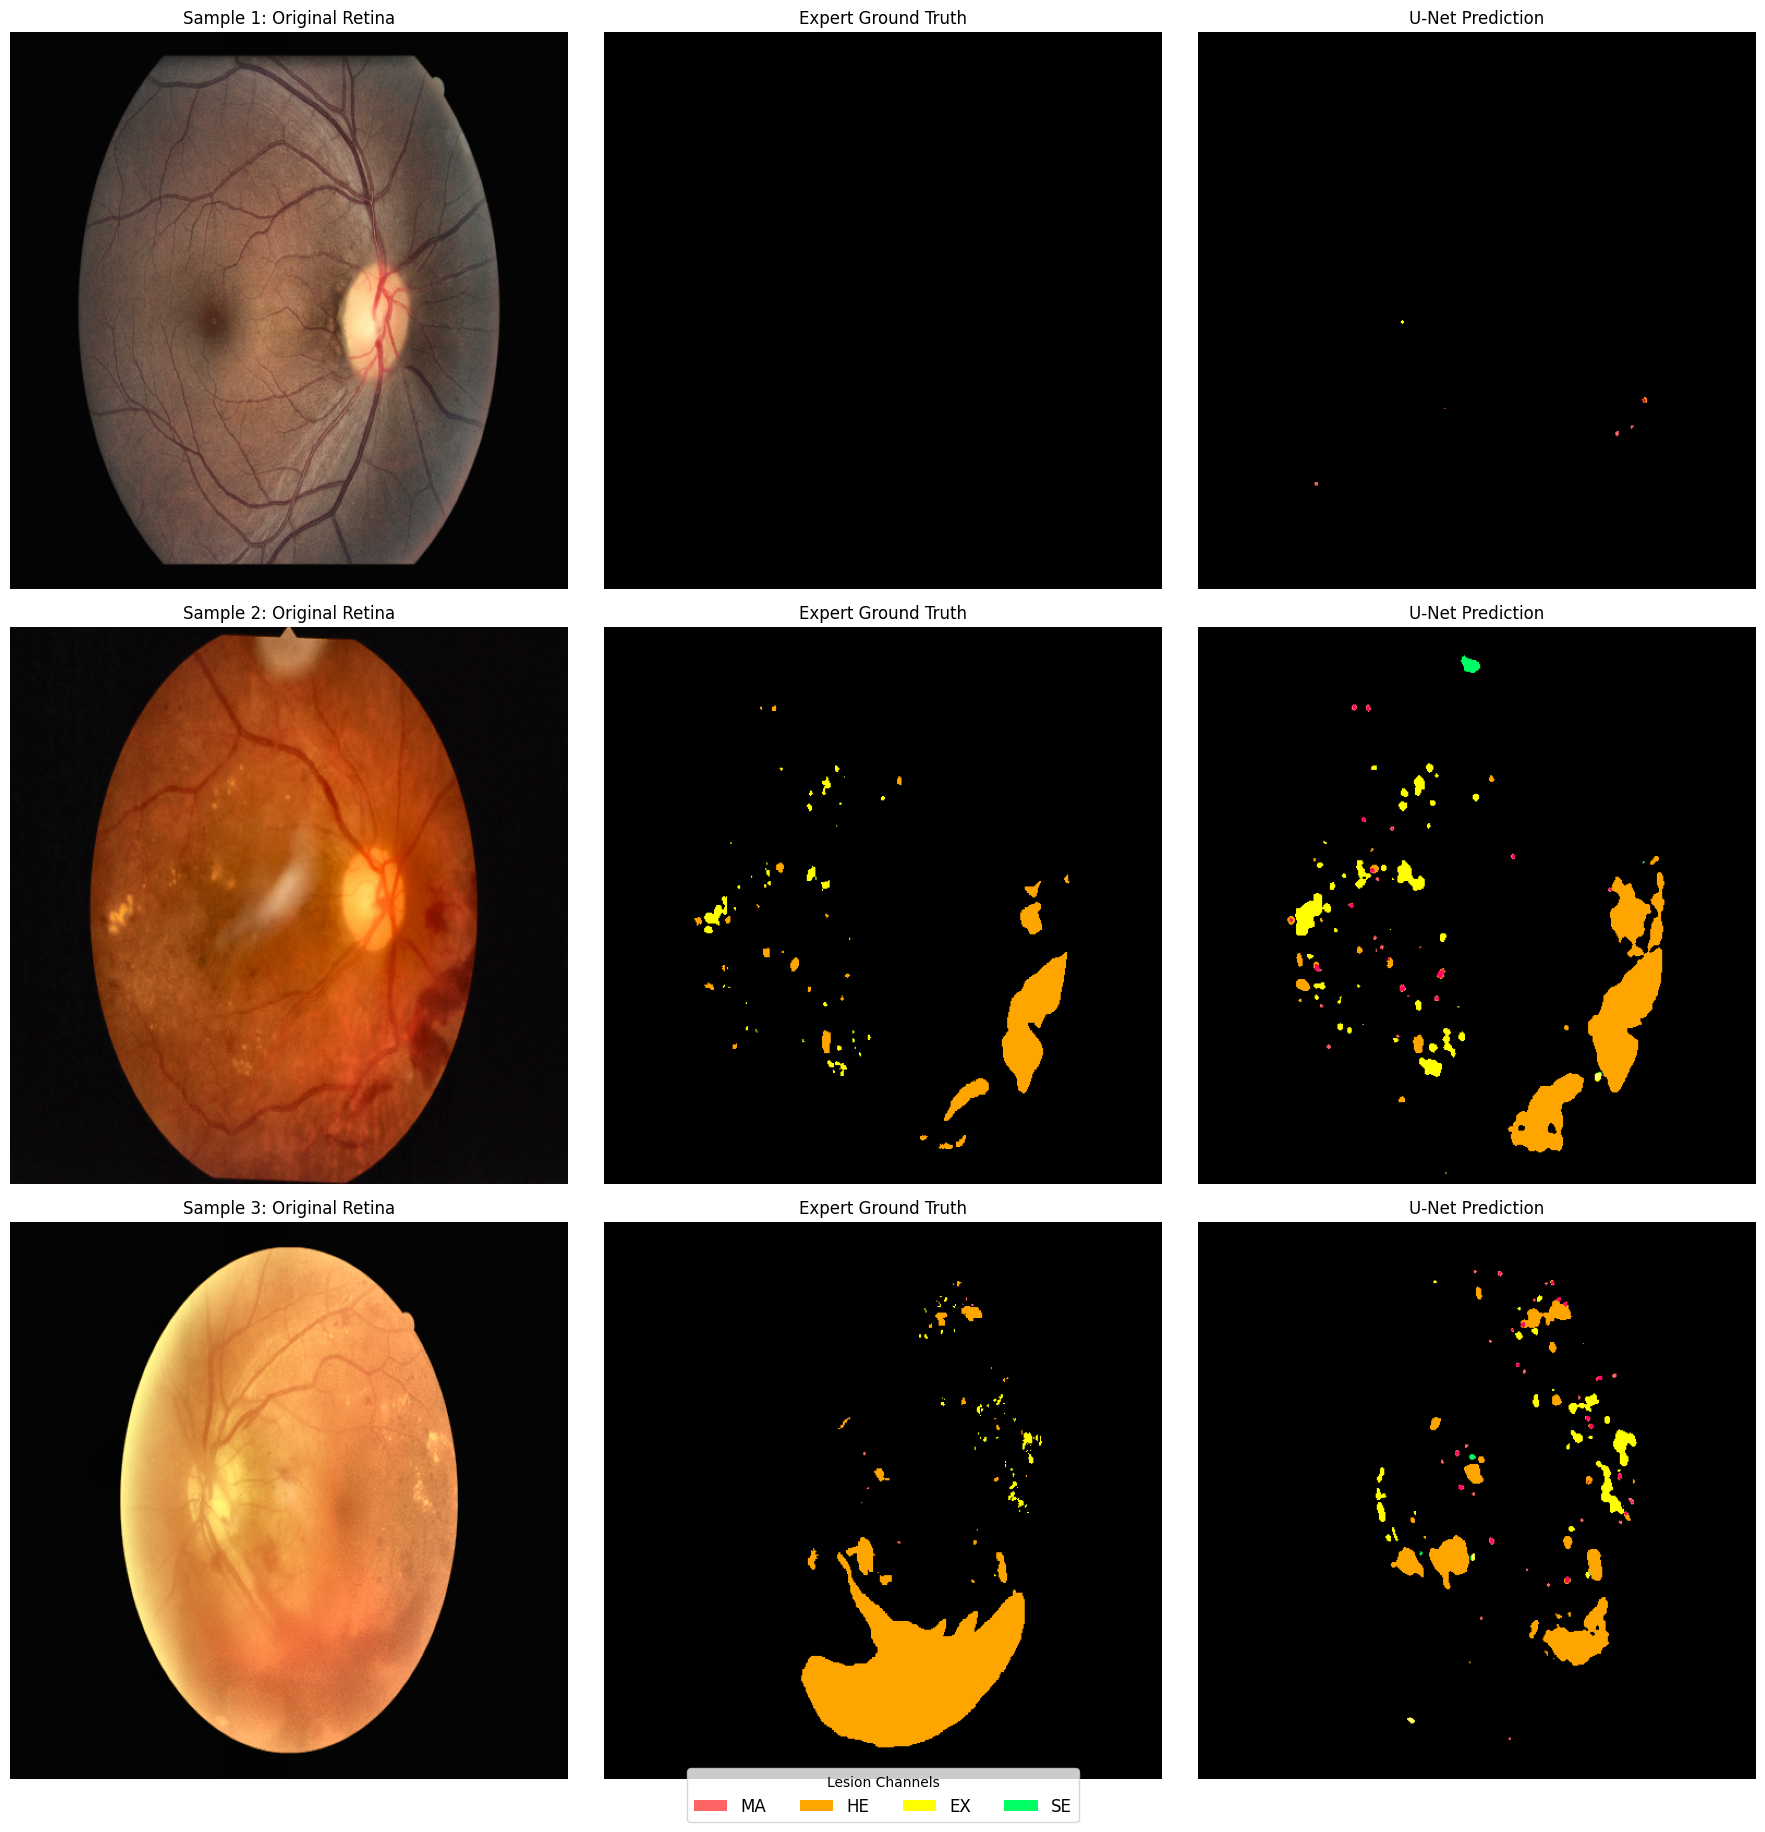

In [12]:
# --- CELL 8: MAIN TRAINING LOOP ---
print(f"🚀 Training on {len(train_imgs)} | Validating on {len(val_imgs)}")

best_val_dice = 0.0
best_ma_he    = 0.0
history       = []
patience      = 15
no_improve    = 0

for epoch in range(1, UNetConfig.epochs + 1):
    train_loss  = train_epoch(model, train_loader, optimizer, criterion, scheduler, UNetConfig.device)
    val_metrics = validate_epoch(model, val_loader, criterion, UNetConfig.device)
    current_lr  = optimizer.param_groups[0]['lr']

    print(f"\n--- Epoch {epoch}/{UNetConfig.epochs} ---")
    print(f"LR: {current_lr:.6f}")
    print(f"Train Loss: {train_loss:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"📊 MA: {val_metrics['ma_dice']:.3f} | HE: {val_metrics['he_dice']:.3f} | "
          f"EX: {val_metrics['ex_dice']:.3f} | SE: {val_metrics['se_dice']:.3f}")

    # ✅ FIX: save best overall model based on macro dice
    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), "unet_best_overall.pth")
        print("⭐ Best overall model saved!")

    # ✅ FIX: early stopping tied to the same metric we save on (macro dice)
    # Previously: saved on dice but early-stopped on MA+HE — inconsistent
    current_ma_he = val_metrics['ma_dice'] + val_metrics['he_dice']
    if current_ma_he > best_ma_he:
        best_ma_he = current_ma_he
        torch.save(model.state_dict(), "unet_best_ma_he.pth")
        print("⭐ Best MA+HE model saved!")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⏹ Early stopping at epoch {epoch} (no MA+HE improvement for {patience} epochs)")
            break

    val_metrics['train_loss'] = train_loss
    val_metrics['epoch']      = epoch
    history.append(val_metrics)

# --- Summary ---
print(f"\n✅ Best Overall Dice : {best_val_dice:.4f}")
print(f"✅ Best MA+HE Score  : {best_ma_he:.4f}")

# ✅ ADD: training curve plot
epochs_ran = [h['epoch']      for h in history]
train_losses = [h['train_loss'] for h in history]
val_losses   = [h['loss']       for h in history]
val_dices    = [h['dice']       for h in history]
ma_dices     = [h['ma_dice']    for h in history]
he_dices     = [h['he_dice']    for h in history]
ex_dices     = [h['ex_dice']    for h in history]
se_dices     = [h['se_dice']    for h in history]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs_ran, train_losses, label='Train Loss')
axes[0].plot(epochs_ran, val_losses,   label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, val_dices, label='Macro Dice', linewidth=2)
axes[1].plot(epochs_ran, ma_dices,  label='MA',  linestyle='--')
axes[1].plot(epochs_ran, he_dices,  label='HE',  linestyle='--')
axes[1].plot(epochs_ran, ex_dices,  label='EX',  linestyle='--')
axes[1].plot(epochs_ran, se_dices,  label='SE',  linestyle='--')
axes[1].set_title('Per-Channel Dice')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# --- Final Visual Audit ---
print("\n🔍 Final Visual Audit...")
check_visuals(model, val_ds, UNetConfig.device, num_samples=3)